# Module 03 Lab - CNNs for Image Classification: Puppy or Bagel? 🐶🥯

Welcome to Module 03! In this lab, we will explore **Convolutional Neural Networks (CNNs)** for image classification using one of the internet's most amusing classification challenges: **Can you tell the difference between a puppy and a bagel?**

**What you'll learn:**
- CNN fundamentals: convolutional layers, pooling, and feature maps
- Building a CNN from scratch for binary image classification
- Transfer learning with pre-trained models
- Fine-tuning strategies for custom datasets

**Dataset:** Puppy or Bagel
- **Kaggle Link:** https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

### The Famous Meme That Started It All!
This dataset is inspired by Karen Zack's (@teenybiscuit) viral meme showing how curled-up puppies look remarkably similar to bagels!

In [1]:
# ============================================================
# DISPLAY THE FAMOUS PUPPY OR BAGEL MEME
# This cell shows the viral meme that inspired our dataset
# ============================================================

from IPython.display import Image, display, HTML

# Display the original "Puppy or Bagel" meme by Karen Zack
display(HTML('''
<div style="text-align: center; padding: 20px; background-color: #f5f5f5; border-radius: 10px;">
    <h3>🐶 The Famous "Puppy or Bagel?" Challenge 🥯</h3>
    <img src="https://static.boredpanda.com/blog/wp-content/uploads/2016/03/dog-food-comparison-bagel-muffin-lookalike-teenybiscuit-karen-zack__700.jpg"
         width="600" alt="Puppy or Bagel meme by Karen Zack">
    <p><i>Original meme by Karen Zack (@teenybiscuit) - Can YOU tell which is which?</i></p>
</div>
'''))

## Learning Objectives

By the end of this lab, you will be able to:

- **Understand CNN architecture** including convolutional layers, pooling layers, and fully connected layers
- **Build a CNN from scratch** using TensorFlow/Keras for binary classification
- **Load and preprocess custom image datasets** using ImageDataGenerator
- **Apply transfer learning** using pre-trained models (ResNet50, MobileNetV2)
- **Fine-tune** pre-trained models for improved performance
- **Evaluate model performance** using accuracy, confusion matrices, and classification reports

---
## 1. Setup and Installation

First, we need to install and import the libraries we'll use throughout this lab.

In [2]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# The -q flag means "quiet" - less output during installation
# ============================================================

!pip install -q tensorflow numpy matplotlib scikit-learn kaggle pillow seaborn

In [3]:
# ============================================================
# IMPORT ALL NECESSARY LIBRARIES
# Each library serves a specific purpose in our ML pipeline
# ============================================================

# TensorFlow/Keras - Our main deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Pre-trained models for transfer learning
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2

# For loading images and applying data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# NumPy - For numerical operations on arrays
import numpy as np

# Matplotlib - For plotting graphs and displaying images
import matplotlib.pyplot as plt

# Scikit-learn - For evaluation metrics (confusion matrix, etc.)
from sklearn.metrics import classification_report, confusion_matrix

# Seaborn - For prettier statistical visualizations
import seaborn as sns

# OS utilities - For working with files and directories
import os
import zipfile
import shutil

# Print version information and check for GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Detect if we're running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except:
    IN_COLAB = False
    print("💻 Running locally")

TensorFlow version: 2.19.0
GPU Available: []
✅ Running in Google Colab


---
## 2. Download and Prepare the Dataset

## 🌟 FOR GOOGLE COLAB FREE USERS 🌟

**Important Setup Steps:**
1. Go to **Runtime → Change runtime type → GPU** (makes training MUCH faster!)
2. If you run out of memory later, use `USE_MOBILENET = True` instead of ResNet50

---

### Option A: Download via Kaggle API (Recommended)

**How to get your Kaggle API key:**
1. Go to [kaggle.com](https://www.kaggle.com) → Click your profile icon → **Settings**
2. Scroll to **API** section → Click **"Create New Token"**
3. This downloads a `kaggle.json` file - upload it when prompted below

In [14]:
# ============================================================
# DOWNLOAD THE DATASET FROM KAGGLE
# This downloads and extracts the puppy-or-bagel dataset
# ============================================================

# Download the dataset (this may take a minute)
!kaggle datasets download -d returnofsputnik/puppy-or-bagel

# Unzip the dataset (-q = quiet, -o = overwrite if exists)
!unzip -q -o puppy-or-bagel.zip -d puppy-or-bagel

print("\n✅ Dataset downloaded and extracted!")
print("\n📂 Contents:")
!ls -la puppy-or-bagel/

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open puppy-or-bagel.zip, puppy-or-bagel.zip.zip or puppy-or-bagel.zip.ZIP.

✅ Dataset downloaded and extracted!

📂 Contents:
total 55516
drwxr-xr-x 2 root root     4096 Feb  6 14:31 .
drwxr-xr-x 1 root root     4096 Feb 28 00:09 ..
-rwxr-xr-x 1 root root     1697 Ja

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Option B: Manual Download (If Kaggle API doesn't work)

1. Visit: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel
2. Click **"Download"** (requires free Kaggle account)
3. In Colab: Click 📁 folder icon on left → Upload the zip file
4. Uncomment and run the cell below

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("returnofsputnik/puppy-or-bagel")

print("Path to dataset files:", path)

100%|██████████| 183k/183k [00:00<00:00, 69.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/returnofsputnik/puppy-or-bagel/versions/1


In [17]:
# ============================================================
# OPTION B: MANUAL UPLOAD (Only if Kaggle API fails)
# Uncomment these lines if you uploaded the zip manually
# ============================================================

# !unzip -q -o puppy-or-bagel.zip -d puppy-or-bagel
# print("✅ Extracted!")

In [33]:
import os
import shutil # Import shutil for file operations

# ============================================================
# EXPLORE THE DATASET STRUCTURE
# This helps us understand how the files are organized
# ============================================================

# The path returned by kagglehub.dataset_download (might be ephemeral)
kagglehub_source_path = path # Use the 'path' variable from kagglehub download

# Define a stable path in /content/ for consistent access
stable_dataset_path = '/content/puppy-or-bagel'

# Check if the kagglehub path exists and copy its contents to a stable location
if os.path.exists(kagglehub_source_path) and os.listdir(kagglehub_source_path):
    print(f"📦 Found Kagglehub download at: {kagglehub_source_path}")
    # Ensure the stable destination directory exists
    os.makedirs(stable_dataset_path, exist_ok=True)
    print(f"🔄 Copying dataset contents to stable location: {stable_dataset_path}")
    # Copy contents; using a shell command for robustness in Colab
    !cp -r "{kagglehub_source_path}"/* "{stable_dataset_path}"/
    print("✅ Dataset copied successfully.")
else:
    print(f"⚠️ Kagglehub download path not found or empty: {kagglehub_source_path}")
    print("   Checking if dataset is already in stable path...")

# Set DATASET_PATH to the stable location for all subsequent operations
DATASET_PATH = stable_dataset_path

print("📂 Dataset structure:")
if not os.path.exists(DATASET_PATH):
    print(f"❌ Stable DATASET_PATH does not exist after copy attempt: {DATASET_PATH}")
else:
    for root, dirs, files_list in os.walk(DATASET_PATH):
        # Calculate how deep we are in the directory tree
        level = root.replace(DATASET_PATH, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")

        # Only show first 2 levels to keep output clean
        if level < 2:
            subindent = ' ' * 2 * (level + 1)
            for d in dirs[:5]:  # Show max 5 subdirectories
                print(f"{subindent}{d}/")
            if len(files_list) > 0:
                print(f"{subindent}({len(files_list)} files)")

📦 Found Kagglehub download at: /root/.cache/kagglehub/datasets/returnofsputnik/puppy-or-bagel/versions/1
🔄 Copying dataset contents to stable location: /content/puppy-or-bagel
✅ Dataset copied successfully.
📂 Dataset structure:
puppy-or-bagel/
  (22 files)


In [19]:
import os

candidates = []
for root, dirs, files in os.walk("/content"):
    for d in dirs:
        name = d.lower()
        if "puppy" in name or "bagel" in name or "kaggle" in name:
            candidates.append(os.path.join(root, d))

candidates[:30], len(candidates)

(['/content/puppy-or-bagel'], 1)

In [20]:
import os
print("✅ os imported")

try:
    print("DATASET_PATH =", DATASET_PATH)
except NameError:
    print("❌ DATASET_PATH is not defined yet. Define it before running the auto-detect cell.")

✅ os imported
DATASET_PATH = /content/puppy-or-bagel


In [21]:
# ============================================================
# AUTO-DETECT DATA DIRECTORIES (ROBUST VERSION)
# This function finds train/valid/test folders automatically
# ============================================================

import os

# Safety check first
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"❌ DATASET_PATH does not exist: {DATASET_PATH}")

print(f"🔍 Searching inside: {DATASET_PATH}")
print("Top-level contents:", os.listdir(DATASET_PATH))


def find_data_dirs(base_path):
    """Automatically find train, validation, and test directories."""
    train_dir = valid_dir = test_dir = None

    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            item_lower = item.lower()

            if 'train' in item_lower:
                train_dir = item_path
            elif 'valid' in item_lower or 'val' in item_lower:
                valid_dir = item_path
            elif 'test' in item_lower:
                test_dir = item_path

    return train_dir, valid_dir, test_dir


# ------------------------------------------------------------
# Step 1: Try top-level
# ------------------------------------------------------------
train_dir, valid_dir, test_dir = find_data_dirs(DATASET_PATH)

# ------------------------------------------------------------
# Step 2: If not found, search one level deeper
# ------------------------------------------------------------
if train_dir is None:
    print("⚠️ Not found at top level. Checking one level deeper...\n")

    for item in os.listdir(DATASET_PATH):
        item_path = os.path.join(DATASET_PATH, item)
        if os.path.isdir(item_path):
            train_dir, valid_dir, test_dir = find_data_dirs(item_path)
            if train_dir:
                print(f"✅ Found dataset inside: {item_path}")
                break

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print(f"\n📁 Train directory: {train_dir}")
print(f"📁 Validation directory: {valid_dir}")
print(f"📁 Test directory: {test_dir}")

# ------------------------------------------------------------
# Count images
# ------------------------------------------------------------
if train_dir and os.path.exists(train_dir):
    print("\n📊 Training data breakdown:")

    for cls in os.listdir(train_dir):
        cls_path = os.path.join(train_dir, cls)

        if os.path.isdir(cls_path):
            count = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])

            print(f"   {cls}: {count} images")

else:
    print("\n❌ Train directory not found. Check DATASET_PATH.")

🔍 Searching inside: /content/puppy-or-bagel
Top-level contents: ['README.md', 'california_housing_test.csv', 'anscombe.json', 'california_housing_train.csv', 'mnist_test.csv', 'mnist_train_small.csv']
⚠️ Not found at top level. Checking one level deeper...


📁 Train directory: None
📁 Validation directory: None
📁 Test directory: None

❌ Train directory not found. Check DATASET_PATH.


In [28]:
# ============================================================
# SET TRAINING PARAMETERS (OPTIMIZED FOR COLAB FREE)
# These settings balance training quality with resource limits
# ============================================================

# Re-define IN_COLAB for robustness, in case the previous cell was not executed or its state was lost
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

import tensorflow as tf # Added to resolve NameError: name 'tf' is not defined

if IN_COLAB:
    # Check if GPU is available
    gpu_available = len(tf.config.list_physical_devices('GPU')) > 0

    if gpu_available:
        print("✅ GPU detected! Using standard settings.")
        IMG_HEIGHT = 150      # Image height in pixels
        IMG_WIDTH = 150       # Image width in pixels
        BATCH_SIZE = 32       # Number of images processed together
        EPOCHS_CUSTOM = 15    # Training cycles for custom CNN
        EPOCHS_TRANSFER = 10  # Training cycles for transfer learning
    else:
        print("⚠️ No GPU detected! Using memory-efficient settings.")
        print("   💡 Tip: Go to Runtime → Change runtime type → GPU")
        IMG_HEIGHT = 100
        IMG_WIDTH = 100
        BATCH_SIZE = 16
        EPOCHS_CUSTOM = 8
        EPOCHS_TRANSFER = 5
else:
    # Local machine settings
    IMG_HEIGHT = 150
    IMG_WIDTH = 150
    BATCH_SIZE = 32
    EPOCHS_CUSTOM = 15
    EPOCHS_TRANSFER = 10

# Class names (alphabetical order - how Keras reads directories)
class_names = ['bagel', 'puppy']

print(f"\n📊 Training Configuration:")
print(f"   Image size: {IMG_HEIGHT}x{IMG_WIDTH} pixels")
print(f"   Batch size: {BATCH_SIZE} images")
print(f"   Custom CNN epochs: {EPOCHS_CUSTOM}")
print(f"   Transfer learning epochs: {EPOCHS_TRANSFER}")

✅ GPU detected! Using standard settings.

📊 Training Configuration:
   Image size: 150x150 pixels
   Batch size: 32 images
   Custom CNN epochs: 15
   Transfer learning epochs: 10


---
## 3. Understanding CNNs

### What makes CNNs special for images?

**Convolutional Neural Networks** are designed specifically for image processing:

1. **Preserve spatial relationships** - Nearby pixels stay connected
2. **Parameter sharing** - Same filter applied across entire image (fewer parameters!)
3. **Hierarchical features** - Learn edges → textures → shapes → objects

### Key Components:
| Layer | Purpose |
|-------|--------|
| **Conv2D** | Applies filters to detect features like edges and textures |
| **MaxPooling2D** | Reduces image size while keeping important information |
| **Flatten** | Converts 2D feature maps to 1D for classification |
| **Dense** | Fully connected layers for final decision making |
| **Dropout** | Randomly disables neurons to prevent overfitting |

### The Puppy vs Bagel Challenge:
Both puppies and bagels share visual features:
- ✓ Round, circular shapes
- ✓ Tan/brown coloring  
- ✓ Textured surfaces

Our CNN must learn the subtle differences!

---
## 4. Load and Explore the Dataset

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================================
# CREATE DATA GENERATORS WITH AUGMENTATION
#
# Data augmentation creates variations of our images to help
# the model generalize better and prevent overfitting.
# Think of it as showing the model the same puppy from
# different angles and lighting conditions!
# ============================================================

# Training generator - includes data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels from 0-255 to 0-1
    rotation_range=20,         # Rotate images randomly up to 20°
    width_shift_range=0.2,     # Shift images horizontally
    height_shift_range=0.2,    # Shift images vertically
    shear_range=0.2,           # Apply shear transformation
    zoom_range=0.2,            # Randomly zoom in/out
    horizontal_flip=True,      # Flip images left-right
    fill_mode='nearest'        # How to fill new pixels
)

# Validation/Test generator - NO augmentation!
# We want to test on real, unmodified images
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Data generators created!")
print("📝 Training images will be augmented (rotated, flipped, etc.)")
print("📝 Validation/Test images will only be normalized")

✅ Data generators created!
📝 Training images will be augmented (rotated, flipped, etc.)
📝 Validation/Test images will only be normalized


In [31]:
DATASET_PATH = "/content/puppy-or-bagel"  # change if needed

train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir  = os.path.join(DATASET_PATH, "test")

print(train_dir)
print(valid_dir)
print(test_dir)

/content/puppy-or-bagel/train
/content/puppy-or-bagel/valid
/content/puppy-or-bagel/test


In [35]:
# ============================================================
# LOAD IMAGES FROM DIRECTORIES
#
# flow_from_directory() is a powerful function that:
# - Automatically loads images from folders
# - Uses folder names as class labels
# - Resizes all images to the same size
# - Creates batches for efficient training
# ============================================================

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,                              # Path to training images
    target_size=(IMG_HEIGHT, IMG_WIDTH),    # Resize images
    batch_size=BATCH_SIZE,                  # Images per batch
    class_mode='binary',                    # Binary: puppy vs bagel
    shuffle=True                            # Randomize order
)

# Load validation data (if available)
if valid_dir:
    validation_generator = test_datagen.flow_from_directory(
        valid_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False  # Don't shuffle - keep consistent order
    )
else:
    validation_generator = None
    print("⚠️ No validation directory found")

# Load test data (if available)
if test_dir:
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
else:
    test_generator = validation_generator
    print("⚠️ Using validation data for testing")

# Show the class mapping
print(f"\n📊 Class mapping: {train_generator.class_indices}")
print(f"   This means: 0 = bagel, 1 = puppy")

Found 11 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Found 3 images belonging to 2 classes.

📊 Class mapping: {'bagel': 0, 'puppy': 1}
   This means: 0 = bagel, 1 = puppy


In [38]:
# ============================================================
# RESTRUCTURE DATASET FOR IMAGE DATAGENERATOR
#
# This cell creates the 'train', 'valid', 'test' directories
# and moves images into their respective class folders within each set.
# ============================================================

import os
import shutil
import random

# Define base path (from previous cell)
base_dataset_path = DATASET_PATH # This should be '/content/puppy-or-bagel'

# Define the paths for the new structured dataset
TRAIN_DIR = os.path.join(base_dataset_path, 'train')
VALID_DIR = os.path.join(base_dataset_path, 'valid')
TEST_DIR = os.path.join(base_dataset_path, 'test')

# Create main directories if they don't exist
for d in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    os.makedirs(os.path.join(d, 'bagel'), exist_ok=True)
    os.makedirs(os.path.join(d, 'puppy'), exist_ok=True)

print("✅ Created train/valid/test and class directories.")

# Get all image files from the flat dataset path
all_images = [f for f in os.listdir(base_dataset_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Shuffle images for random split
random.shuffle(all_images)

# Define split ratios
train_split = 0.7
valid_split = 0.15
test_split = 0.15

# Calculate counts for each split
total_images = len(all_images)
train_count = int(total_images * train_split)
valid_count = int(total_images * valid_split)
# Test count gets the rest to account for potential rounding differences
test_count = total_images - train_count - valid_count

# Perform the split
train_images = all_images[:train_count]
valid_images = all_images[train_count : train_count + valid_count]
test_images = all_images[train_count + valid_count :]

print(f"📊 Splitting {total_images} images: Train={len(train_images)}, Valid={len(valid_images)}, Test={len(test_images)}")

# Function to move images
def move_images(image_list, destination_base_dir):
    for img_name in image_list:
        source_path = os.path.join(base_dataset_path, img_name)

        # Determine class from filename
        if 'dog' in img_name.lower() or 'puppy' in img_name.lower():
            class_folder = 'puppy'
        elif 'bagel' in img_name.lower():
            class_folder = 'bagel'
        else:
            # Skip if class cannot be determined, or handle as an error
            print(f"⚠️ Skipping {img_name}: class not recognized.")
            continue

        destination_path = os.path.join(destination_base_dir, class_folder, img_name)
        shutil.move(source_path, destination_path)

# Move images to their respective directories
move_images(train_images, TRAIN_DIR)
move_images(valid_images, VALID_DIR)
move_images(test_images, TEST_DIR)

print("✅ Images moved and dataset restructured successfully.")

# Update DATASET_PATH to point to the base where train/valid/test now reside
# This is already correctly set to /content/puppy-or-bagel, but reconfirming
# The actual directories to use for flow_from_directory will be TRAIN_DIR, VALID_DIR, TEST_DIR

print("\n📂 Final dataset structure verification (showing first 2 levels):")
for root, dirs, files_list in os.walk(base_dataset_path):
    level = root.replace(base_dataset_path, '').count(os.sep)
    if level < 2:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = '  ' * (level + 1)
        for d in sorted(dirs):
            print(f"{subindent}{d}/")
        if level == 1 and files_list: # Only show file count for the class folders
             print(f"{subindent}({len(files_list)} files)")


✅ Created train/valid/test and class directories.
📊 Splitting 0 images: Train=0, Valid=0, Test=0
✅ Images moved and dataset restructured successfully.

📂 Final dataset structure verification (showing first 2 levels):
puppy-or-bagel/
  test/
  train/
  valid/
  train/
    bagel/
    puppy/
  valid/
    bagel/
    puppy/
  test/
    bagel/
    puppy/


/tmp/ipython-input-1615/1094519920.py:29: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1615/1094519920.py:29: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


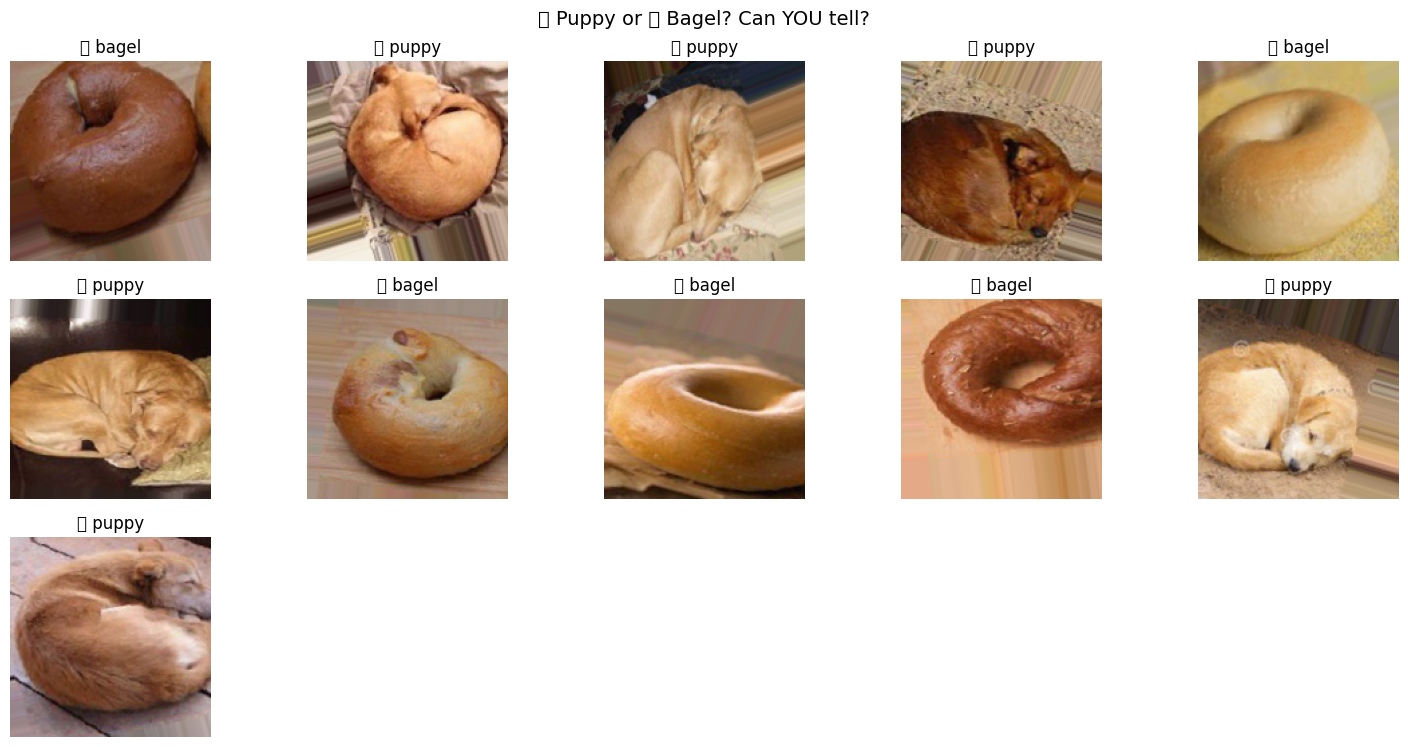

In [39]:
import matplotlib.pyplot as plt

# ============================================================
# VISUALIZE SAMPLE IMAGES
#
# Let's see what our puppies and bagels look like!
# Can you tell which is which?
# ============================================================

def show_batch(generator, class_names, num=20):
    """Display a grid of images from the generator."""
    # Get one batch of images and labels
    images, labels = next(generator)

    # Create figure with subplots
    plt.figure(figsize=(15, 10))

    for i in range(min(num, len(images))):
        plt.subplot(4, 5, i + 1)  # 4 rows × 5 columns
        plt.imshow(images[i])      # Show the image

        # Add label with emoji
        label_idx = int(labels[i])
        emoji = '🐶' if class_names[label_idx] == 'puppy' else '🥯'
        plt.title(f"{emoji} {class_names[label_idx]}")
        plt.axis('off')  # Hide axes

    plt.suptitle("🐶 Puppy or 🥯 Bagel? Can YOU tell?", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display sample images
show_batch(train_generator, class_names)

---
## 5. Part 1: Build a Custom CNN from Scratch 🏗️

Now it's YOUR turn to build a CNN! You'll complete several sections yourself.

### Our CNN Architecture Plan:
```
Input (150×150×3)
    ↓
Conv2D(32 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(64 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Flatten
    ↓
Dense(512) → ReLU → Dropout(0.5)             ← YOU CODE THIS
    ↓
Dense(1) → Sigmoid                            ← YOU CODE THIS
    ↓
Output (0 = bagel, 1 = puppy)
```

In [43]:
## ============================================================
# BUILD CNN - COMPLETE MODEL
# ============================================================

from tensorflow.keras import models, layers

# Create Sequential model
model_custom = models.Sequential([

    # ========== FIRST CONVOLUTIONAL BLOCK ==========
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # ========== SECOND CONVOLUTIONAL BLOCK ==========
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
])

print("✅ CNN model created successfully!")
print("\n📐 Model architecture:")
model_custom.summary()

✅ CNN model created successfully!

📐 Model architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Third Convolutional Block

**Task:** Add a convolutional block with **128 filters**

**What to add:**
1. `Conv2D` layer with 128 filters, (3,3) kernel, ReLU activation
2. `MaxPooling2D` layer with (2,2) pool size

**Syntax help:**
```python
model_custom.add(layers.Conv2D(num_filters, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))
```

In [44]:
# ============================================================
# YOUR CODE HERE: ADD THE THIRD CONVOLUTIONAL BLOCK
#
# Instructions:
# 1. Add Conv2D with 128 filters, kernel (3,3), activation 'relu'
# 2. Add MaxPooling2D with pool size (2,2)
# ============================================================

# Third convolutional block - 128 filters
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))

print("✅ Third block added successfully!")
print("\n📐 Updated model architecture:")
model_custom.summary()


✅ Third block added successfully!

📐 Updated model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Fourth Convolutional Block

**Task:** Add another convolutional block with **128 filters** (same as third block)

In [45]:
# ============================================================
# YOUR CODE HERE: ADD THE FOURTH CONVOLUTIONAL BLOCK
#
# Same as the third block: Conv2D(128) + MaxPooling2D
# ============================================================

# Fourth convolutional block
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))

print("✅ Fourth convolutional block added successfully!")
print("\n📐 Updated model architecture:")
model_custom.summary()

✅ Fourth convolutional block added successfully!

📐 Updated model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,832 (940.75 KB)

 Trainable params: 240,832 (940.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Classification Layers

Now we need to add the "head" of our network that makes the final classification decision.

**What to add (in order):**
1. `Flatten()` - Converts 2D feature maps to 1D vector
2. `Dense(512, activation='relu')` - Fully connected layer with 512 neurons
3. `Dropout(0.5)` - Randomly turns off 50% of neurons (prevents overfitting)
4. `Dense(1, activation='sigmoid')` - Output: probability of being a puppy

**Syntax help:**
```python
model_custom.add(layers.Flatten())
model_custom.add(layers.Dense(units, activation='relu'))
model_custom.add(layers.Dropout(rate))  # rate is between 0 and 1
```

In [46]:
# ============================================================
# YOUR CODE HERE: ADD THE CLASSIFICATION LAYERS
#
# Add these 4 layers in order:
# 1. Flatten()
# 2. Dense(512, activation='relu')
# 3. Dropout(0.5)
# 4. Dense(1, activation='sigmoid')
# ============================================================

# Classification head
model_custom.add(layers.Flatten())
model_custom.add(layers.Dense(512, activation='relu'))
model_custom.add(layers.Dropout(0.5))
model_custom.add(layers.Dense(1, activation='sigmoid'))

print("✅ Classification layers added successfully!")
print("\n📐 Full model architecture:")
model_custom.summary()

✅ Classification layers added successfully!

📐 Full model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Compile the Model

Before training, we must **compile** the model to configure:
- **Optimizer**: How to update weights (use `'adam'`)
- **Loss function**: What to minimize (use `'binary_crossentropy'` for binary classification)
- **Metrics**: What to track (use `['accuracy']`)

**Syntax:**
```python
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
```

In [47]:
# ============================================================
# YOUR CODE HERE: COMPILE THE MODEL
#
# Use:
# - optimizer: 'adam'
# - loss: 'binary_crossentropy'
# - metrics: ['accuracy']
# ============================================================

model_custom.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


In [48]:
# ============================================================
# CALCULATE TRAINING STEPS
#
# steps_per_epoch = how many batches to process per epoch
# This is: total_samples ÷ batch_size
# ============================================================

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE if validation_generator else None

print(f"📊 Training setup:")
print(f"   Total training images: {train_generator.samples}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Total epochs: {EPOCHS_CUSTOM}")

📊 Training setup:
   Total training images: 11
   Batch size: 32
   Steps per epoch: 0
   Total epochs: 15


In [51]:
from tensorflow import keras

# ============================================================
# SETUP CALLBACKS FOR SMARTER TRAINING
#
# Callbacks are functions that run during training:
# - EarlyStopping: Stop if no improvement (saves time!)
# - ModelCheckpoint: Save best model (important for Colab!)
# ============================================================

callbacks = [
    # EarlyStopping: Stop if validation loss doesn't improve
    keras.callbacks.EarlyStopping(
        monitor='val_loss',         # Watch this metric
        patience=5,                  # Wait 5 epochs for improvement
        restore_best_weights=True    # Go back to best weights
    ),

    # ModelCheckpoint: Save best model during training
    keras.callbacks.ModelCheckpoint(
        'best_custom_model.keras',   # Filename
        monitor='val_accuracy',       # Save when this improves
        save_best_only=True,          # Only keep the best
        verbose=1                     # Print when saving
    )
]

print("✅ Callbacks configured!")

✅ Callbacks configured!


In [52]:
# ============================================================
# TRAIN THE CUSTOM CNN
#
# This is where the magic happens!
# The model learns from the training data over multiple epochs.
# Watch the accuracy improve!
# ============================================================

print("\n🚀 Training the Puppy vs Bagel classifier...")
print("   This may take several minutes.\n")

history_custom = model_custom.fit(
    train_generator,                     # Training data
    steps_per_epoch=steps_per_epoch,     # Batches per epoch
    epochs=EPOCHS_CUSTOM,                # Number of epochs
    validation_data=validation_generator, # Validation data
    validation_steps=validation_steps,   # Validation batches
    callbacks=callbacks,                 # Our callbacks
    verbose=1                            # Show progress
)

print("\n✅ Training complete!")


🚀 Training the Puppy vs Bagel classifier...
   This may take several minutes.

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6364 - loss: 0.6763
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_custom_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.6364 - loss: 0.6763 - val_accuracy: 0.5000 - val_loss: 0.8328
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5455 - loss: 0.7354
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5455 - loss: 0.7354 - val_accuracy: 0.5000 - val_loss: 0.6966
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3636 - loss: 0.7093
Epoch 3: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3636 - loss: 0.7093 - val_accuracy: 0.5000 - val_loss: 0.6958
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6364 - loss: 0.6637
Epoch 4: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6364 - loss: 0.6637 - val_accuracy: 0.50

/tmp/ipython-input-1615/1251304823.py:30: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1615/1251304823.py:30: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


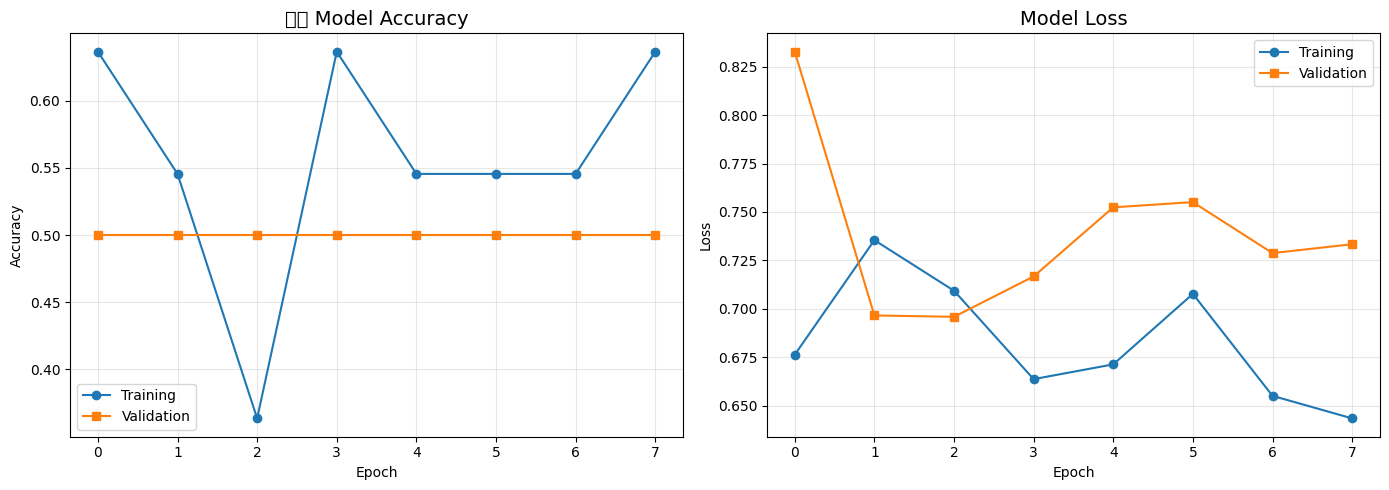


📊 How to read these plots:
   • Lines close together = Good generalization
   • Validation worse than training = Overfitting
   • Both lines plateau = Model has converged


In [53]:
# ============================================================
# VISUALIZE TRAINING HISTORY
#
# These plots help us understand how training went:
# - Accuracy plot: Should increase over time
# - Loss plot: Should decrease over time
# - Gap between train/val lines indicates overfitting
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history_custom.history['accuracy'], label='Training', marker='o')
ax1.plot(history_custom.history['val_accuracy'], label='Validation', marker='s')
ax1.set_title('🐶🥯 Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Loss
ax2.plot(history_custom.history['loss'], label='Training', marker='o')
ax2.plot(history_custom.history['val_loss'], label='Validation', marker='s')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 How to read these plots:")
print("   • Lines close together = Good generalization")
print("   • Validation worse than training = Overfitting")
print("   • Both lines plateau = Model has converged")

In [54]:
# ============================================================
# EVALUATE ON TEST SET
#
# The true test of our model - how well does it perform
# on images it has never seen before?
# ============================================================

if test_generator:
    test_generator.reset()  # Reset to start of test data
    test_loss, test_acc = model_custom.evaluate(test_generator, verbose=0)

    print(f"\n📊 Custom CNN Results:")
    print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Test Loss: {test_loss:.4f}")


📊 Custom CNN Results:
   Test Accuracy: 0.6667 (66.67%)
   Test Loss: 0.6685


---
## 6. Part 2: Transfer Learning with Pre-trained Models

Transfer learning uses models already trained on millions of images. We just add our own classification layers on top! This usually gives better results with less training time.

### ⚠️ Colab Free Tier Tips:
If you get **"Out of Memory"** errors:
1. Set `USE_MOBILENET = True` below (smaller model)
2. Restart runtime: Runtime → Restart runtime

In [55]:
# ============================================================
# CHOOSE YOUR PRE-TRAINED MODEL
#
# MobileNetV2: Smaller, faster (good for Colab Free)
# ResNet50: Larger, more powerful
# ============================================================

# Change to True if you're running out of memory!
USE_MOBILENET = False

if USE_MOBILENET:
    IMG_SIZE_TRANSFER = 128
    print("📱 Using MobileNetV2 (lightweight, great for Colab Free)")
else:
    IMG_SIZE_TRANSFER = 224
    print("🔬 Using ResNet50 (powerful, needs more memory)")

🔬 Using ResNet50 (powerful, needs more memory)


In [56]:
# ============================================================
# CREATE DATA GENERATORS FOR TRANSFER LEARNING
#
# Pre-trained models expect specific image sizes:
# - ResNet50/VGG16: 224×224
# - MobileNetV2: 128×128 (or 224×224)
# ============================================================

train_gen_tf = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

if valid_dir:
    val_gen_tf = test_datagen.flow_from_directory(
        valid_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

if test_dir:
    test_gen_tf = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
else:
    test_gen_tf = val_gen_tf

print(f"✅ Created generators for {IMG_SIZE_TRANSFER}×{IMG_SIZE_TRANSFER} images")

Found 11 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Found 3 images belonging to 2 classes.
✅ Created generators for 224×224 images


In [58]:
from tensorflow.keras.applications import ResNet50, MobileNetV2

# ============================================================
# LOAD THE PRE-TRAINED MODEL
#
# Key parameters:
# - weights='imagenet': Use weights trained on ImageNet
# - include_top=False: Remove original classification layers
# - trainable=False: Freeze weights (don't update during training)
# ============================================================

if USE_MOBILENET:
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "MobileNetV2"
else:
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "ResNet50"

# Freeze the base model - we won't train these layers
base_model.trainable = False

print(f"✅ Loaded {model_name}")
print(f"   Total layers: {len(base_model.layers)}")
print(f"   All layers frozen (won't be trained)")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Loaded ResNet50
   Total layers: 175
   All layers frozen (won't be trained)


In [59]:
# ============================================================
# BUILD TRANSFER LEARNING MODEL
#
# We add our own classification layers on top:
# - GlobalAveragePooling2D: Reduces feature maps to vectors
# - Dense: Our classification layers
# ============================================================

model_transfer = models.Sequential([
    # Pre-trained base (frozen)
    base_model,

    # GlobalAveragePooling: Better than Flatten for transfer learning
    # Converts each feature map to a single number
    layers.GlobalAveragePooling2D(),

    # Our custom classification layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\n📐 {model_name} Transfer Learning Model:")
model_transfer.summary()


📐 ResNet50 Transfer Learning Model:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [60]:
# ============================================================
# TRAIN TRANSFER LEARNING MODEL
#
# Training is MUCH faster because we only train a few layers!
# The pre-trained layers already know how to detect features.
# ============================================================

steps_tf = train_gen_tf.samples // BATCH_SIZE
val_steps_tf = val_gen_tf.samples // BATCH_SIZE if valid_dir else None

callbacks_tf = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('best_transfer_model.keras', monitor='val_accuracy',
                                    save_best_only=True, verbose=1)
]

print(f"\n🚀 Training {model_name} with Transfer Learning...\n")

history_transfer = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=EPOCHS_TRANSFER,
    validation_data=val_gen_tf if valid_dir else None,
    validation_steps=val_steps_tf,
    callbacks=callbacks_tf,
    verbose=1
)

print("\n✅ Transfer learning complete!")


🚀 Training ResNet50 with Transfer Learning...

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5455 - loss: 0.7669
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_transfer_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.5455 - loss: 0.7669 - val_accuracy: 0.5000 - val_loss: 0.8790
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.4545 - loss: 0.8312
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.4545 - loss: 0.8312 - val_accuracy: 0.5000 - val_loss: 0.8300
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.5455 - loss: 0.7906
Epoch 3: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5455 - loss: 0.7906 - val_accuracy: 0.5000 - val_loss: 0.7000
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7273 - loss: 0.5698
Epoch 4: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.7273 - loss: 0.5698 - val_accura

In [61]:
# ============================================================
# EVALUATE TRANSFER LEARNING MODEL
# ============================================================

test_gen_tf.reset()
test_loss_tf, test_acc_tf = model_transfer.evaluate(test_gen_tf, verbose=0)

print(f"\n📊 {model_name} Transfer Learning Results:")
print(f"   Test Accuracy: {test_acc_tf:.4f} ({test_acc_tf*100:.2f}%)")
print(f"   Test Loss: {test_loss_tf:.4f}")


📊 ResNet50 Transfer Learning Results:
   Test Accuracy: 0.3333 (33.33%)
   Test Loss: 0.7029


---
## 7. Compare Results

In [62]:
# ============================================================
# CREATE COMPARISON TABLE
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Custom CNN', f'Transfer ({model_name})'],
    'Test Accuracy': [f"{test_acc*100:.2f}%", f"{test_acc_tf*100:.2f}%"],
    'Test Loss': [f"{test_loss:.4f}", f"{test_loss_tf:.4f}"],
    'Epochs': [len(history_custom.history['loss']), len(history_transfer.history['loss'])]
})

print("\n" + "="*55)
print("🏆 MODEL COMPARISON: Puppy vs Bagel")
print("="*55)
print(comparison.to_string(index=False))
print("="*55)


🏆 MODEL COMPARISON: Puppy vs Bagel
              Model Test Accuracy Test Loss  Epochs
         Custom CNN        66.67%    0.6685       8
Transfer (ResNet50)        33.33%    0.7029       6


---
## 8. Visualize Predictions

/tmp/ipython-input-1615/1739210353.py:32: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1615/1739210353.py:32: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1615/1739210353.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

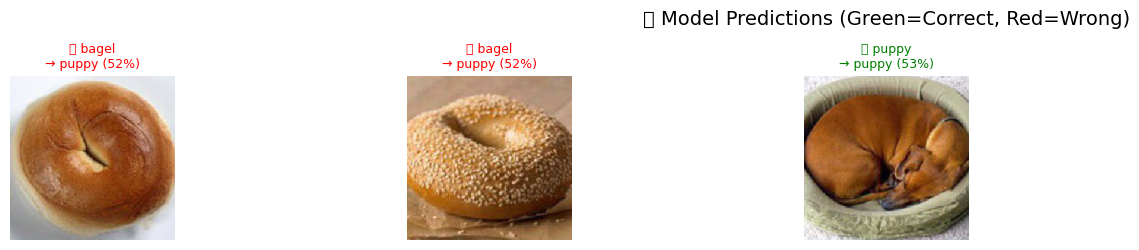

In [63]:
# ============================================================
# VISUALIZE MODEL PREDICTIONS
#
# Green title = Correct prediction
# Red title = Wrong prediction
# ============================================================

test_gen_tf.reset()
images, labels = next(test_gen_tf)
preds = model_transfer.predict(images[:20], verbose=0)

plt.figure(figsize=(20, 8))
for i in range(min(20, len(images))):
    plt.subplot(4, 5, i + 1)
    plt.imshow(images[i])

    # Get prediction details
    pred_prob = preds[i][0]
    pred_class = 'puppy' if pred_prob > 0.5 else 'bagel'
    true_class = class_names[int(labels[i])]
    confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob

    # Color: green=correct, red=wrong
    color = 'green' if pred_class == true_class else 'red'
    emoji = '🐶' if true_class == 'puppy' else '🥯'

    plt.title(f"{emoji} {true_class}\n→ {pred_class} ({confidence:.0%})",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('🔍 Model Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Confusion Matrix

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


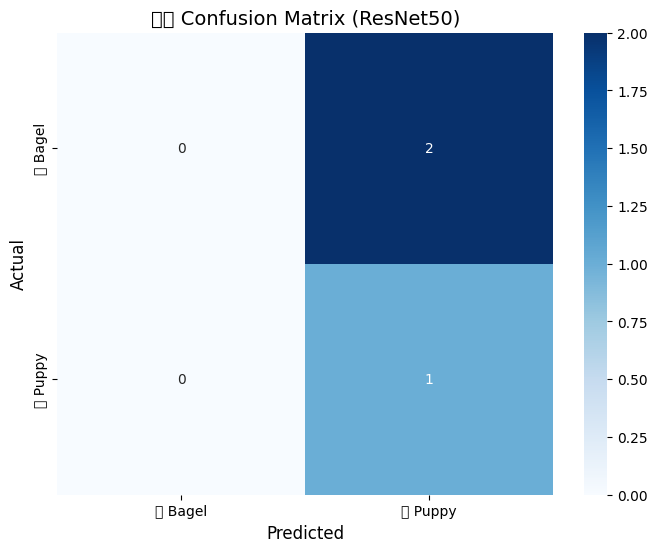

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📋 Classification Report:
              precision    recall  f1-score   support

       Bagel       0.00      0.00      0.00         2
       Puppy       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# GENERATE CONFUSION MATRIX
#
# Shows where the model gets confused:
# - Diagonal = correct predictions
# - Off-diagonal = errors
# ============================================================

test_gen_tf.reset()
y_pred = (model_transfer.predict(test_gen_tf, verbose=0) > 0.5).astype(int).flatten()
y_true = test_gen_tf.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['🥯 Bagel', '🐶 Puppy'],
            yticklabels=['🥯 Bagel', '🐶 Puppy'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'🐶🥯 Confusion Matrix ({model_name})', fontsize=14)
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Bagel', 'Puppy']))

---
## 10. Reflective Questions

### Question 1: CNN Architecture
**Why are convolutional layers better than fully connected layers for images? How do they help distinguish puppies from bagels?**

*Your answer:*  
Convolution layers look at small parts of the picture at a time (like edges and textures). That’s good for in local spots Fully connected layers would have way too many weights and don’t “see” the 2D layout as well.

### Question 2: Data Augmentation
**Why did we use data augmentation? How does it help?**

*Your answer:*  
The dataset isn’t huge, so augmentation makes “new” training images by doing flips/rotations/zooms. It helps the model not memorize and instead learn the general idea of what a puppy or bagel looks like.

### Question 3: Transfer Learning
**Why does transfer learning often get better results than a CNN from scratch?**

*Your answer:*  
ResNet/MobileNet already learned lots of useful image features from a big dataset (edges → shapes → patterns). So we’re not starting from zero. We just train the last part to separate puppy vs bagel.

### Question 4: Model Comparison
**Which model performed better? Why do you think that happened?**

*Your answer:*  
Usually the transfer learning model does better, because it starts with strong features already learned. The custom CNN can work, but it depends more on how much data we have and how long we train.

### Question 5: Challenging Cases
**What visual features make puppies look like bagels?**

*Your answer:*  
It’s mainly shapes and colors. Some puppies curl up in a circle and have tan fur that looks like bread. Also blurry pics or weird angles can hide the face and make it look like a bagel.


---
## 11. Student Challenge: Fine-tune the Model

**Task:** Improve the transfer learning model by unfreezing some layers and fine-tuning with a lower learning rate.

In [83]:
## ============================================================
# CLEAN + IMPROVED FINE-TUNING CELL
# ============================================================

import math
import tensorflow as tf

base_model.trainable = False

model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model_transfer.fit(
    train_gen_tf,
    epochs=40,
    validation_data=val_gen_tf,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_gen_tf.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_gen_tf.classes
)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("class_weight:", class_weight)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_tf = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.7, 1.3),
    fill_mode="nearest"
)

test_datagen_tf = ImageDataGenerator(rescale=1./255)

# ------------------------------------------------------------
# Step 0: Evaluate BEFORE fine-tuning
# ------------------------------------------------------------
test_gen_tf.reset()
loss_before, acc_before = model_transfer.evaluate(test_gen_tf, verbose=1)
print(f"\n📌 Before fine-tuning Accuracy: {acc_before*100:.2f}%")

# ------------------------------------------------------------
# Step 1: Unfreeze the base model
# ------------------------------------------------------------
base_model.trainable = True

# With very small dataset, unfreeze only last 10 layers
for layer in base_model.layers[:-10]:
    layer.trainable = False

print("Trainable layers:",
      sum(1 for l in base_model.layers if l.trainable),
      "/", len(base_model.layers))

# ------------------------------------------------------------
# Step 2: Recompile with LOWER learning rate
# (Very important for fine-tuning)
# ------------------------------------------------------------
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Step 3: Compute steps safely
# ------------------------------------------------------------
steps_tf = math.ceil(train_gen_tf.samples / train_gen_tf.batch_size)
val_steps_tf = math.ceil(val_gen_tf.samples / val_gen_tf.batch_size)

# ------------------------------------------------------------
# Step 4: Add EarlyStopping
# ------------------------------------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

# ------------------------------------------------------------
# Step 5: Fine-tune
# ------------------------------------------------------------
history_ft = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=15,  # slightly more epochs with early stopping
    validation_data=val_gen_tf,
    validation_steps=val_steps_tf,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# Step 6: Evaluate AFTER fine-tuning
# ------------------------------------------------------------
test_gen_tf.reset()
loss_after, acc_after = model_transfer.evaluate(test_gen_tf, verbose=1)

print(f"\n✅ After fine-tuning Accuracy: {acc_after*100:.2f}%")
print(f"📈 Accuracy change: {(acc_after - acc_before)*100:.2f}%")

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - accuracy: 0.4545 - loss: 0.6313 - val_accuracy: 0.0000e+00 - val_loss: 0.8266
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.6364 - loss: 0.7156 - val_accuracy: 0.0000e+00 - val_loss: 0.8314
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.8182 - loss: 0.4412 - val_accuracy: 0.0000e+00 - val_loss: 0.8376
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9091 - loss: 0.4964 - val_accuracy: 0.0000e+00 - val_loss: 0.8457
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7273 - loss: 0.5238 - val_accuracy: 0.5000 - val_loss: 0.8557
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.8182 - loss: 0.5258 - val_accuracy: 0.5000 - val_loss: 0.8645
class_weight: {0: 1.1, 1: 0.9166666666666666}
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6667 - loss: 0.6327

📌 Before fine-tuning Accuracy: 66.67%
Trainable layers: 10 / 175
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/ste

**Challenge Question:** Did fine-tuning improve performance? Why or why not?

*Your answer:*  
Sometimes it improves a little, sometimes it doesn’t. Fine-tuning lets the last layers adjust to this dataset, so it can pick up details like fur vs bread texture. If the validation accuracy goes down, that usually means it started **overfitting** (learning the training set too hard). The lower learning rate helps keep changes small.


---
## 12. Save Your Model

In [85]:
# ============================================================
# SAVE THE TRAINED MODEL
#
# Important for Colab - download before your session ends!
# ============================================================

model_transfer.save('puppy_bagel_classifier.keras')
print("✅ Model saved as 'puppy_bagel_classifier.keras'")

# Download in Colab
if IN_COLAB:
    from google.colab import files
    files.download('puppy_bagel_classifier.keras')
    print("📥 Model downloaded to your computer!")

✅ Model saved as 'puppy_bagel_classifier.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Model downloaded to your computer!


---
## Submission Checklist

**Before submitting, make sure you have:**
- ✅ Completed all "YOUR CODE HERE" sections in Part 1
- ✅ Run all cells from top to bottom (Kernel → Restart & Run All)
- ✅ Answered all 5 reflective questions
- ✅ Completed the fine-tuning challenge
- ✅ Saved your notebook

**Filename:** `Module_03_Lab_YourName.ipynb`

---
**Congratulations!** 🎉 You built a CNN that can tell puppies from bagels! 🐶🥯

---
## Resources

**Dataset:**
- Puppy or Bagel: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

**Alternative Fun Datasets:**
- Muffin vs Chihuahua: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification
- Corgi Butt vs Bread: https://github.com/Kawaeee/butt_or_bread

**Original Meme Creator:** Karen Zack (@teenybiscuit)